# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: Ejemplo de Geodésicas

In [1]:
!pip install -Uq einsteinpy


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import einsteinpy.symbolic as es
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [3]:
g, x, c = sp.symbols('g x c')
gmat = np.diag([1+2*g*x/c**2, -1, -1, -1])
gmat

array([[1 + 2*g*x/c**2, 0, 0, 0],
       [0, -1, 0, 0],
       [0, 0, -1, 0],
       [0, 0, 0, -1]], dtype=object)

In [4]:
coordenadas = sp.symbols('T x y z') # T = ct
gmet = es.MetricTensor(gmat, coordenadas)
gmet

MetricTensor[[1 + 2*g*x/c**2, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, -1]]

In [5]:
gtensor = gmet.tensor()
gtensor

[[1 + 2*g*x/c**2, 0, 0, 0], [0, -1, 0, 0], [0, 0, -1, 0], [0, 0, 0, -1]]

In [6]:
G = es.ChristoffelSymbols.from_metric(gmet)
G.tensor()

[[[0, g/(c**2 + 2*g*x), 0, 0], [g/(c**2 + 2*g*x), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[g/c**2, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]]

In [7]:
G[0]

[[0, g/(c**2 + 2*g*x), 0, 0], [g/(c**2 + 2*g*x), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]]

In [8]:
G[0, 0, 1] # G[sigma (el de arriba), mu, nu (los de abajo)]

g/(c**2 + 2*g*x)

In [9]:
from IPython.display import display

In [10]:
xpp = sp.symbols(r'\ddot{T} \ddot{x} \ddot{y} \ddot{z}')
xp = sp.symbols(r'\dot{T} \dot{x} \dot{y} \dot{z}')
display(xpp[0]), display(xp[1])

\ddot{T}

\dot{x}

(None, None)

In [11]:
for sigma in range(4):
    ecuacion = 0
    for mu in range(4):
        for nu in range(4):
            ecuacion += -G[sigma, mu, nu] * xp[mu] * xp[nu]

    ecuacion = sp.Eq(xpp[sigma],ecuacion)
    display(ecuacion)

Eq(\ddot{T}, -2*\dot{T}*\dot{x}*g/(c**2 + 2*g*x))

Eq(\ddot{x}, -\dot{T}**2*g/c**2)

Eq(\ddot{y}, 0)

Eq(\ddot{z}, 0)

In [12]:
def edg_galileo(tau, Ys, g, c):
    T, x, y, z, Ut, Ux, Uy, Uz = Ys

    # Derivadas
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz

    # Derivadas de U
    dUt_dtau = -2*Ut*Ux*g / (c**2 + 2*g*x)
    dUx_dtau = -Ut**2 * g / c**2
    dUy_dtau = 0
    dUz_dtau = 0

    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau, 
            dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

In [13]:
edg_galileo(1, [1, 1, 1, 1, 1, 1, 1, 1], 9.8, 1)

[1, 1, 1, 1, -0.9514563106796117, -9.8, 0, 0]

## A resolver pues...

Unidades:

In [14]:
import pymcel as pc

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [15]:
# Unidades relativistas: c = 1, c = UL / UT
UL = 1 # en metros
UT = UL / pc.constantes.c
UV = UL / UT
UA = UL / UT**2
C = 1

UL, UT, UV, UA, C

(1,
 np.float64(3.3356409519815204e-09),
 np.float64(299792458.0),
 np.float64(8.987551787368178e+16),
 1)

Condiciones iniciales:

In [16]:
t0 = 0
x0 = 10 / UL # 10 metros en unidades relativistas
y0 = 0 / UL
z0 = 0 / UL

vx0 = 1 / UV # 1 m/s en unidades relativistas
vy0 = 0 / UV
vz0 = 0 / UV

Condiciones iniciales en el espacio-tiempo:

In [17]:
T0 = C*t0
# Las posiciones son las mismas
g = 9.8 / UA # m/s2 en unidades relativistas
g00 = 1 + 2*g*x0 / C**2
g11 = g22 = g33 = -1
Ut0 = 1 / np.sqrt(g00 + g11*vx0**2 + g22*vy0**2 + g33*vz0**2)
Ux0 = vx0 * Ut0 / C
Uy0 = vy0 * Ut0 / C
Uz0 = vz0 * Ut0 / C

Tiempos y condiciones iniciales:

In [18]:
from scipy.integrate import solve_ivp

In [20]:
taus = np.linspace(0, 1 / UT, 100)
Ys0 = [T0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]
solucion = solve_ivp(edg_galileo, (taus[0], taus[-1]), Ys0, t_eval=taus, args=(g, C))

Extraemos la solución y la ponemos en unidades del sistema internacional:

In [37]:
ts = solucion.y[0] / C * UT
xs = solucion.y[1] * UL
ys = solucion.y[2] * UL
zs = solucion.y[3] * UL

Graficamos:

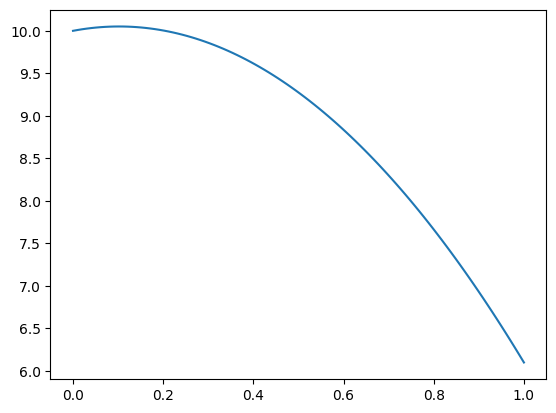

In [38]:
plt.plot(ts, xs)

Comparemos con lo que esperamos según la cinemática galileana:

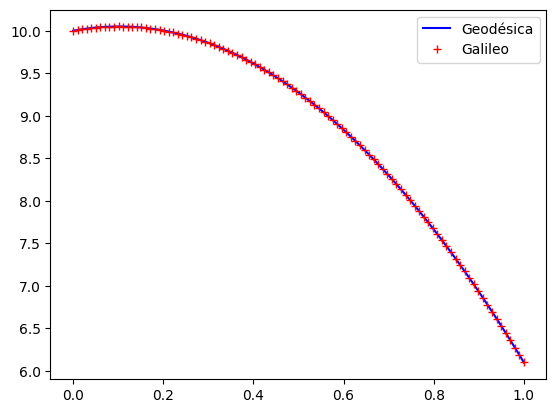

In [39]:
# x = x0 + v0 * t - 1/2 * g * t**2
x0 = x0 * UL
v0 = vx0 * UV
g = 9.8

xgalileos = x0 + v0 * ts - 1/2 * g * ts**2

plt.plot(ts, xs, 'b-', label='Geodésica')
plt.plot(ts, xgalileos, 'r+', label='Galileo')
plt.legend()

Que coincide exactamente.